In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize
from scipy import stats
import statsmodels.formula.api as smf 
# Turn on a setting to use Pandas more safely.
# We will discuss this setting ®later.
pd.set_option('mode.chained_assignment', 'raise')

# Also - set up plotting
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

### Collaborative environments

- Google colab - needs a google account.  Colab is here: <https://colab.google/>
- Deepnote - sign up here: <https://deepnote.com/>
- Visual code studio?
  - Possible with a github account
  - Should be possible with a microsoft account, but did not work for me
- Github - for experienced git users
- Exchanging notebooks or submitting individual pieces of a project in separate notebooks
  - Do collaborative code checking/pair programming
  - You can submit more than one notebook
    - Just be sure to include a document that tells us what the different notebooks do

#### Make sure you load your notebook to vlab at the end and check that it runs completely without error
#### Do not use extra tools or AI with the environment that may introduce things that don't work outside of the particular environment you are in

## Multiple regression:
### - Predicting a value with more than one variable (predictor)

How do you analyze data if you want to predict an outcome from more than one predictor?
- e.g.
- Brain age
- Predict actual age from
- white matter hyperintensities
- exercise
  </p>
(simple regression will no longer do)

#### Need: multiple regression

We will look at our permutation techniques

### Example based conceptually on: Huang et al (2022) [but data are invented here]
#### Brain white matter hyperintensities-predicted age reflects neurovascular health in middle-to-old aged subjects

https://academic.oup.com/ageing/article/51/5/afac106/6583203

<img src="WMH_data.png">


#### Make some data - don't worry about what we are doing here for now, just run this cell

In [2]:
d = 2 # Number of dimensions
mean = [10.,20.]
covariance = np.matrix([
[1, 0.1], # 1 is the variance of variable 1, 0.2 is the covariance of variable 1 and 2
[0.1, 1]  #
])

### Look at how your two **predictors** are related
- In the plot below these look pretty unrelated, which is good
- When they are highly related there are several possibilities
    - pred1 is important and pred2 is not
    - pred2 is important and pred1 is not
    - both pred1 and pred2 are important in some ratio (which might be 50/50, but might be some other value)
 <br>
 
 When two variables are high correlated the statistics can't sort this out for you.  You have to use theory or run and experiment where you manipulate the variables orthogonally (you may need to look up what that means).
<br>

This is the "problem of collinearity"

#### Here, however, we don't have that problem
 

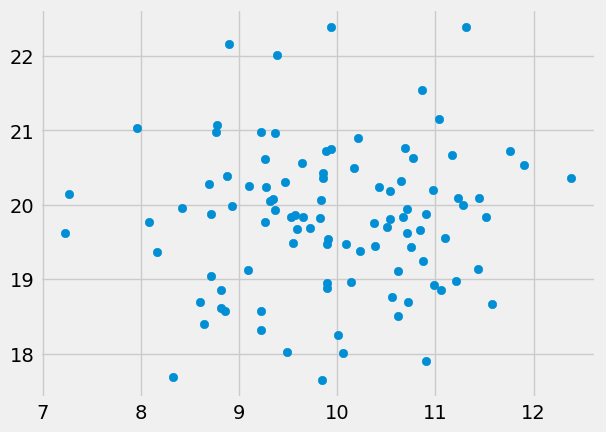

In [5]:
number_of_samples = 100
z = np.random.multivariate_normal(mean=mean, cov=covariance, size=number_of_samples)
x = np.transpose(z)
# Plot density function.
plt.scatter(x=x[0],y=x[1])

In [6]:
# Make y data based on our two predictor datasets and a model
# Since we are creating the data ourselves we can decide how the predictor variables are related to y (the outcome variable)
# Here y changes by 2 units for every change in x[0] (pred1)
# y change by -0.4 units for every change in x[1] (pred2)

intercept = np.repeat(50,len(x[0]))
noise = np.random.normal(0,0.2,size=len(x[0]))
y = intercept + 2*x[0] + -0.4*x[1] + noise

In [8]:
# set some more informative variable names

pred1 = x[0]
pred2 = x[1]
outcome = y

### Plot individual variables

#### predictor 1

Text(0, 0.5, 'outcome variable - (actual age)')

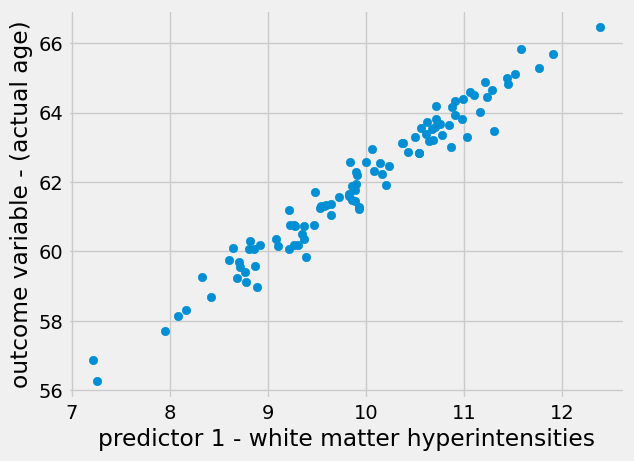

In [9]:
plt.scatter(x=pred1,y=outcome)
plt.xlabel("predictor 1 - white matter hyperintensities")
plt.ylabel("outcome variable - (actual age)")

#### predictor 2 (not in the paper explicitly, but we are adding this in our example)
- Our own Katrien Sagaert has shown that aerobic exercise is important for brain health

Text(0, 0.5, 'outcome variable - (actual age)')

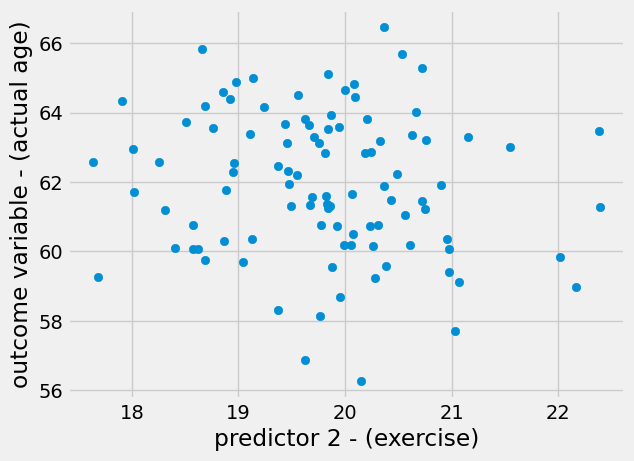

In [10]:
plt.scatter(x=pred2,y=outcome)
plt.xlabel("predictor 2 - (exercise)")
plt.ylabel("outcome variable - (actual age)")

### Which predictor is better?
### Is one not useful?

### Put our predictors into a data frame

In [11]:
data_df = pd.DataFrame()
outcome_df = pd.DataFrame()
outcome_df["age"] = outcome
data_df["WMH"] = pred1
data_df["exercise"] = pred2

### Now we need a general SSE function to use with optimize - remember there was an exercise about this?  Here is the answer:

Predictors: (real data):
e.g. white matter hyperintensities ($x_{1}$); exercise ($x_{2}$)

| intercept | x[1]  | x[2]  |
|-----------|-------|-------|
| all 1s    | (data)| (data)|
|-----------|-------|-------|
|           | WMH   | exercise |
|-----------|-------|-------|
|     1     |  20  |  30  |
|     1     |  15  |  45  |
|     1     |  30  |  10  |
| .         |      |      |
| .         |      |      |
| .         |      |      |

Variable to predict (real data), e.g. $y$ = actual age :
| y values |
|----------|
|actual age|
|----------|
| 50      |
| 62      |
| 36      |
| . |
| . |
| . |

Variables to change:

| intercept | slope $\beta_{1}$ (WMH slope) | slope $\beta_{2}$ (exercise slope) |
|-----------|--------------|--------------|
| starting  | guess for $\beta_{1}$ | guess for $\beta_{2}$ |
| guess for |
| intercept |

To get a prediction for each value y:

$$
y_{predicted} = intercept + (slope_{WMH} \times WMH\_value) + (slope_{exercise} \times exercise\_value)
$$

In matrix form:

$$
\left[\begin{array}{c}
y_1 \\
y_2 \\
y_3
\end{array}\right] = 
\left[\begin{array}{c}
intercept \\
slope_{WMH} \\
slope_{exercise}
\end{array}\right]
\left[\begin{array}{ccc}
1 & WMH_1  & exercise_1\\
1 & WMH_2  & exercise_2\\
1 & WMH_3  & exercise_3\\
\end{array}\right]
$$

$$
y_{predicted} = variables\_to\_change \times Data\_Matrix
$$

$$
squared\ error = (y_{predicted} - y_{actual})^{2}
$$

Sum to get SSE

#### Put that into a function that calculates SSE

In [12]:
def sse(values_to_change,x_values,y_values):
    # values to change are intercept, pred 1, pred 2 ...etc.
    # x_values is a data frame with predictors
    # y_values is an array with outcome data
    values_to_change = np.array(values_to_change)
    predictors = x_values.copy()
    predictors.insert(loc=0, column="intercept",value = np.repeat(1,len(data_df)))
    y_values = np.array(y_values)

    # first column of predictors is 1 and first value to change is the intercept
    #     1 times the intercept just gives the intercept, so that is how we do that
    # the other predictors are slopes - we want each predictor variable data value to be multiplied by its slope
    # Then we want to sum everything - intercept + x[0] * slope for x0 + x[1] * slope for x1 ... etc.
    #    Notice how this is the same equation you will see in multiple regression descriptions
    equation_values = predictors * values_to_change
    predicted_y = equation_values.sum(axis=1)
    error = predicted_y - y_values # compare to actual y-values to get error
    squared_error = error**2 # np.abs(error)
    sse_value = np.sum(squared_error)
    return(sse_value)

In [13]:
# Try out SSE to make sure it works
values_to_change = np.array([20,2,0.4])
sse_value=sse(values_to_change,data_df,outcome_df["age"])
sse_value

20067.853177273217

### First do a simple linear regression for predictor 1
### Put _just the first predictor_ into a dataframe on its own so we can pass the dataframe to optimize.minimize and SSE
- Our SSE wants predictors in a data frame
- SSE is written that way so you can add several columns of predictors if you want

### Do the minimization to get the best line possible using just predictor 1 (pred1) by itself

In [14]:
one_pred = pd.DataFrame()
one_pred["WMH"] = data_df["WMH"].copy()
one_pred_result=optimize.minimize(sse,[5,2],args=(one_pred,outcome_df["age"]))
# our x values are in the one_pred dataframe
# our y values are the "outcome" column from outcome_df

# show the intercept and slope from minimize
one_pred_result.x

array([42.2693385 ,  1.97962755])

Intercept is first value, slope is second


### Is the slope different from zero?

In [15]:
# so we go back to our 'optimize.minimize' statement:
# one_pred_result=optimize.minimize(sse,[5,2],args=(one_pred,outcome_df["outcome"]))
#
# we need to shuffle the values in one_pred do minimize, save slope and intercept and repeat

num_repeats = 1000
random_world_slopes = np.zeros(num_repeats)
random_world_intercepts = np.zeros(num_repeats)
shuffled_x_df = one_pred.copy()
for i in np.arange(0,num_repeats):
    shuffled_x_df["WMH"] = np.random.permutation(shuffled_x_df["WMH"])
    shuffle_model_result = optimize.minimize(sse,[5,2],args=(shuffled_x_df,outcome_df["age"]))
    random_world_intercepts[i] = shuffle_model_result.x[0]
    random_world_slopes[i] = shuffle_model_result.x[1]
print(random_world_intercepts[1:10])
print(random_world_slopes[1:10])

[62.48592178 60.31245782 65.55079746 64.05899828 58.73569761 66.20862036
 60.05220652 57.11228144 62.58351964]
[-0.05513612  0.16361922 -0.36361049 -0.21346352  0.32231737 -0.42981921
  0.18981305  0.48571136 -0.06495918]


### Evaluate the slope

Is the real-world slope rare or common in the shuffled world where x and y are not related?

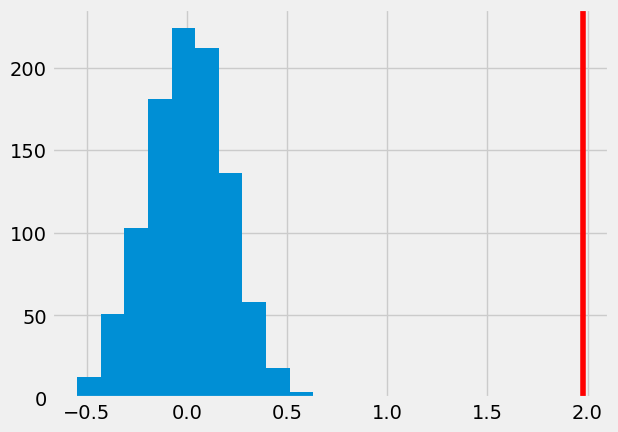

In [16]:
plt.hist(random_world_slopes)
plt.axvline(one_pred_result.x[1],color="red")

In [17]:
# calculate the probability of the real-world slope (one_pred_result.x[1]) in the random world

prob_slope = np.count_nonzero(random_world_slopes >= one_pred_result.x[1])/num_repeats
prob_slope

0.0

### Probability is low

The real-world slope is different from the slopes in the random world

### Check the intercept result - Is the intercept for the real world different from the shuffled world?

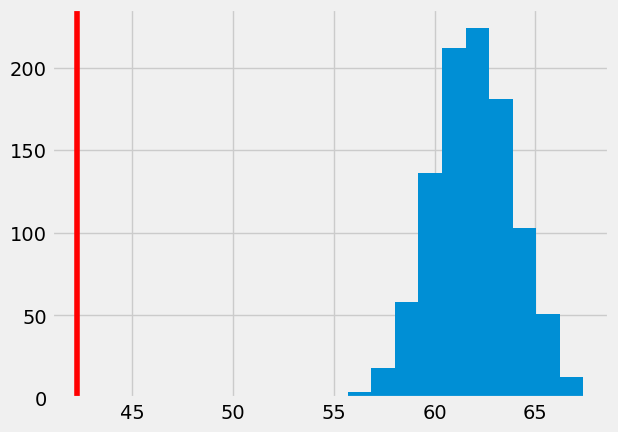

In [18]:
plt.hist(random_world_intercepts)
plt.axvline(one_pred_result.x[0],color="red")

#### How rare is that?

In [19]:
prob_intercept = np.count_nonzero(random_world_intercepts <= one_pred_result.x[0])/num_repeats
prob_intercept

0.0

### Check that with a regression package

#### Put outcome together with predictors in a dataframe so we can pass all to the regression function

In [20]:
include_outcome_df = data_df.copy()
outcomes = np.array(outcome_df["age"])
include_outcome_df.insert(loc=0,column="age",value=np.array(outcome_df["age"]))
include_outcome_df.head()

,age,WMH,exercise
0,61.195159,9.217646,18.311817
1,60.199923,9.309608,20.055767
2,61.711642,9.482225,18.015920
3,63.829261,10.974750,20.204317
4,64.341003,10.903523,17.906304


### reminder of optimize values

In [21]:
one_pred_result.x

array([42.2693385 ,  1.97962755])

In [22]:
model_result = smf.ols(formula = 'age ~ WMH', data = include_outcome_df).fit()
model_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    age   R-squared:                       0.963
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     2543.
Date:                Tue, 05 Dec 2023   Prob (F-statistic):           6.60e-72
Time:                        16:55:57   Log-Likelihood:                -49.690
No. Observations:                 100   AIC:                             103.4
Df Residuals:                      98   BIC:                             108.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     42.2693      0.392    107.795      0.000      41.491      43.047
WMH            1.9796      0.039     50.425      0.000       1.902       2.058
==============================================================================
Omnibus:                        2.635   Durbin-Watson:                   2.260
Prob(Omnibus):                  0.268   Jarque-Bera (JB):                2.122
Skew:                          -0.344   Prob(JB):                        0.346
Kurtosis:                       3.186   Cond. No.                         98.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### slope and intercept match
### p-values also match

### What about our other variable (exercise)?  - Can it help with whatever we haven't been able to predict?

#### We need to take the part that has been predicted out of the outcome variable
 (get the 'residuals' -- what is left over after we have made our prediction)
#### We also need to take any part of predictor2 that is correlated with predictor1 out of predictor2
 take any part of exercise that is correlated with WMH out of exercise
#### Why?  Because we have already used _all_ of predictor 1 (including the part correlated with predictor 2) to predict the outcome. 

- We need to see if what is leftover from our age prediction can be predicted by what is leftover from exercise after we've removed the part correlated with WMH
- How do we do that?
    - predict exercise (pred2) using age (pred1) and then calculate the residuals. Call this residual_exercise(residual_pred2).
    - predict residual_age (residual_y)  using residual_exercise (residual_pred2)

In [24]:
# Predict pred2 using pred1

pred2_with_pred1=optimize.minimize(sse,[1,1],args=(one_pred,data_df["exercise"]))
pred2_with_pred1.x

array([19.34119079,  0.04658429])

In [25]:
predicted_pred2 = pred2_with_pred1.x[0] + (one_pred["WMH"] * pred2_with_pred1.x[1])


Text(0, 0.5, 'exercise (pred 2)')

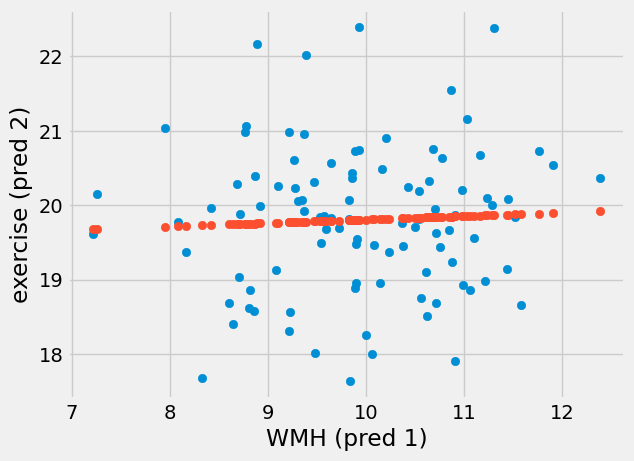

In [26]:
plt.scatter(x=one_pred["WMH"],y=data_df["exercise"])
plt.scatter(x=one_pred["WMH"],y=predicted_pred2)
plt.xlabel("WMH (pred 1)")
plt.ylabel("exercise (pred 2)")

### The part of predictor 2 that we can't predict with predictor 1 is the distance between the red points and the blue points
- That is called the 'residual'
- This is what we will use to try and predict more of the outcome variable
- We **don't** use the raw pred2 values

In [27]:
# what is leftover after our prediction (i.e. the distance between the red and blue points)
# is called a 'residual'
residual_pred2 = data_df["exercise"] - predicted_pred2

### Calculate what is left over to predict from the outcome variable after we predict with pred1
- We need to calculate the difference between the values predicted by pred1 and the real outcome values
- Then we need to see if we can predict the leftovers with the leftovers from pred2 that we calculated just above
- If pred2 helps, we can put both pred1 and pred2 together to predict the outcome value

### Now, what of age (the _outcome variable_) is left to predict after using WMH (pred1)?

In [28]:
# predicted equation is: predicted_value = intercept + (slope * x_value)

predicted_y = one_pred_result.x[0] + (data_df["WMH"] * one_pred_result.x[1])
residual_y = outcome_df["age"] - predicted_y
residual_y

0     0.678314
1    -0.498971
2     0.671030
3    -0.165996
4     0.486750
        ...   
95   -0.288631
96    0.426873
97    0.093838
98    0.261802
99   -0.280247
Length: 100, dtype: float64

### Plot the original data,  prediction and residuals
#### The distance between red and blue points is what is left unpredicted
#### Those values are also 'residuals'

Perhaps some of this left-over variation can be predicted by residual_pred2

Text(0, 0.5, 'age')

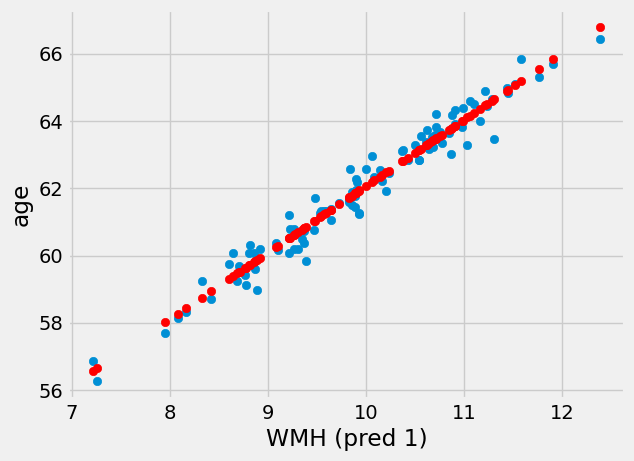

In [29]:
# Original data and predicted values in red

plt.scatter(x=data_df["WMH"],y=outcome_df["age"])
plt.scatter(x=data_df["WMH"],y=predicted_y,color="red")
plt.xlabel("WMH (pred 1)")
plt.ylabel("age")

### Now plot residuals - these are the left over values arranged around zero 
(as if the red line was rotated down to horizontal)

Text(0, 0.5, 'age residual')

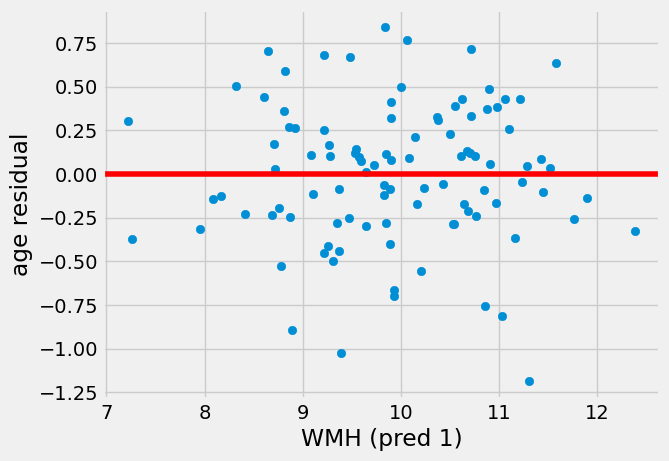

In [31]:
plt.scatter(x=data_df["WMH"],y=residual_y)
plt.axhline(y=0, color="red")
plt.xlabel("WMH (pred 1)")
plt.ylabel("age residual")

### Can the residuals be predicted by our second predictor?
- Plot y_residual against pred2_residuals to see if there is a relationship

Text(0, 0.5, 'residual from age')

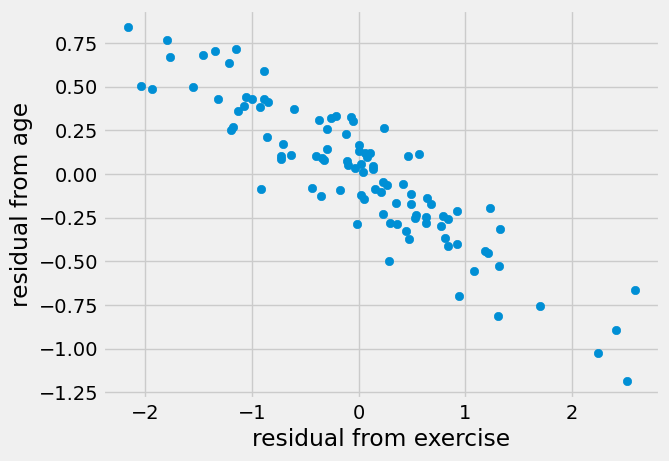

In [32]:
plt.scatter(x=residual_pred2,y=residual_y)
plt.xlabel("residual from exercise")
plt.ylabel("residual from age")

### Does that look like a possible relationship?
- Notice this looks much stronger than the relationship between the outcome and predictor 2 when it was on its own
- What predictor 2 accounts for is much clearer when it is just predicting what is left over after predictor 1
- Note this difference.  A predictor variable can have a different effect on its own compared to when it is combined with another variable

In [33]:
# Put 'pred2' in a dataframe and see if we can predict residual_y with it

residual_pred2_df = pd.DataFrame()
residual_pred2_df["residual_pred2"] = residual_pred2
resid_pred2_result=optimize.minimize(sse,[1,1],args=(residual_pred2_df,residual_y))
resid_pred2_result.x

array([ 1.07374041e-09, -3.73297015e-01])

Text(0, 0.5, 'residual from age')

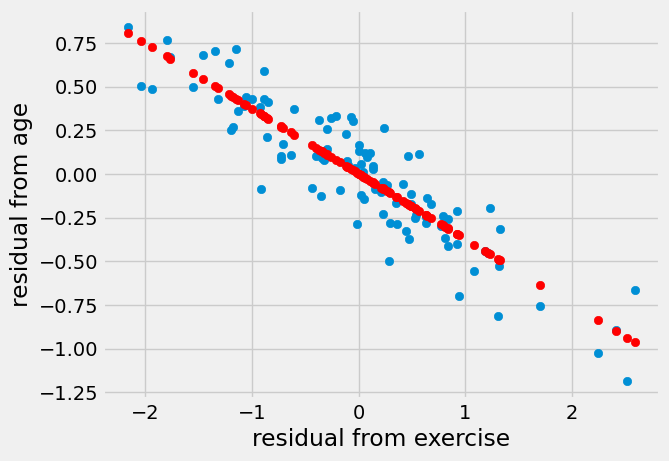

In [34]:
predicted_resid_y_from_resid_pred2 = resid_pred2_result.x[0] + residual_pred2 * resid_pred2_result.x[1]
plt.scatter(x=residual_pred2,y=residual_y)
plt.scatter(x=residual_pred2,y=predicted_resid_y_from_resid_pred2,color="red")
plt.xlabel("residual from exercise")
plt.ylabel("residual from age")

### Check our results with a multiple regression function from stats models

### That matches (slope is the same, intercept is a very small value close to 0)

### What if we put both in a linear regression?

In [35]:
model_result_both = smf.ols(formula = 'outcome ~ pred1 + pred2', data = include_outcome_df).fit()
model_result_both.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     7372.
Date:                Tue, 05 Dec 2023   Prob (F-statistic):          1.10e-106
Time:                        17:09:45   Log-Likelihood:                 37.141
No. Observations:                 100   AIC:                            -68.28
Df Residuals:                      97   BIC:                            -60.47
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     49.4893      0.377    131.221      0.000      48.741      50.238
pred1          1.9970      0.017    120.444      0.000       1.964       2.030
pred2         -0.3733      0.018    -21.302      0.000      -0.408      -0.339
==============================================================================
Omnibus:                        0.655   Durbin-Watson:                   2.402
Prob(Omnibus):                  0.721   Jarque-Bera (JB):                0.790
Skew:                          -0.156   Prob(JB):                        0.674
Kurtosis:                       2.696   Cond. No.                         495.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### check the slopes from step 1 and step 2 compared to the multiple regression package

### Now you know what multiple regression does

It will be a little different if pred1 and pred2 have a more substantial correlation (in that case multiple regression tries to share the credit between the two variables, which would probably make the outcome from a regression function and your outcome from 'optimize.minimize look different).  Here we let the first variable (WMH) take as much credit as it can (no sharing) before giving any credit to exercise

### OK - that is for the slopes.  What about testing whether the slopes are different from zero with permutation?

That process is described in Anderson and Legendre (1998) on page 277 (there are a couple of methods described, but subsequent work generally agrees that permutation of the residuals is best).  Here is the process they use for a second variable in the presence of the first:


1. Do a multiple regression using $Y = X_1 + X_2 + intercept$ to get an estimate of the slope for $X_2$
1. Save that as the real world slope for $X_2$
</p>
1. Do a regression of $Y = X_1 + intercept\_single$ (i.e. without $X_2$) and get the residuals (we did that above here)
1. Get the predicted value of Y (call that $y_p$) from the regression $Y= X_1 + intercept$
1. Calculate the residuals
</p>
1. Shuffle the residuals
1. Add the shuffled residuals to the predicted Y ($y_p$)
1. Fit a multiple regression to $y_p = X_1 + X_2 + intercept$  
</p>
1. Save the fitted value for pred2 ($X_2) and for the intercept
1. Repeat from the step 'Shuffle the residuals'
</p>

See if the real slope for $X_2$ is different from the slope in the shuffled worlds.

### Step by step - step 1 is do the multiple regression

In [94]:
multi_result=optimize.minimize(sse,[1,1,1],args=(data_df,outcome_df["age"]))
multi_result.x
real_world_intercept = multi_result.x[0]
real_world_pred1_slope = multi_result.x[1]
real_world_pred2_slope = multi_result.x[2]
print("intercept: ",real_world_intercept," slope for WMH ",real_world_pred1_slope," slope for exercise: ",real_world_pred2_slope)

intercept:  50.929221669704944  slope for WMH  1.9903398559999212  slope for exercise:  -0.4418219686299872


### Note that the this result matches the one we ran with the regression package from statsmodels above

That's good.  We know our optimize.minimize function is working

#### We've calculated the residuals above (look for a reminder).
#### Now we can shuffle them

In [95]:
# remember that 'residual_y' were the residuals from the regression 
# predicting y from pred1 on its own and predicted_y is the
# predicted value of y using just pred1 as a predictor (also from above)

# shuffled world for testing predictor 2 (x2) 
# Use predicted Y from regression that predicts Y from x1 alone and residuals from the same regression
# Shuffle the residuals and combine the predicted Y and shuffled residuals
num_repeats=1000
shuffled_intercept = np.zeros(num_repeats)
shuffled_pred2_slope = np.zeros(num_repeats)
for i in np.arange(1,num_repeats):
    shuffled_residuals = np.random.permutation(residual_y)
    shuffled_world_y = predicted_y + shuffled_residuals
    shuffle_multi_result=optimize.minimize(sse,[1,1,1],args=(data_df,shuffled_world_y))
    shuffled_intercept[i] = shuffle_multi_result.x[0]
    shuffled_pred2_slope[i] = shuffle_multi_result.x[2]

Text(0.5, 0, 'pred2 slope - shuffled values vs real world (red)')

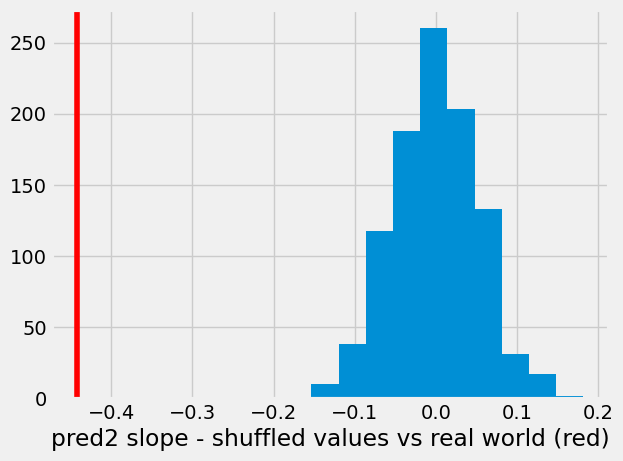

In [96]:
plt.hist(shuffled_pred2_slope)
plt.axvline(x=real_world_pred2_slope,color="red")
plt.xlabel("pred2 slope - shuffled values vs real world (red)")

In [97]:
p_value_slope_pred2 = np.count_nonzero(shuffled_pred2_slope <= real_world_pred2_slope)
p_value_slope_pred2

0

### probability is low - this matches the multiple regression package result

### We can also test WMH (pred1) after exercise (pred2) because this can sometimes change compared to when we predicted the outcome with WMH (pred1) on its own. 

In [99]:
# predict y based only on pred2

one_pred2 = pd.DataFrame()
one_pred2["exercise"] = data_df["exercise"].copy()
pred2_alone_result = optimize.minimize(sse,[1,1],args=(one_pred2, outcome_df["age"]))
pred2_alone_result.x

array([73.68340471, -0.59190052])

In [100]:
# get residuals from pred2 alone regression

predicted_y2 = pred2_alone_result.x[0] + pred2_alone_result.x[1] * one_pred2["exercise"]
residual_y2 = predicted_y2 - outcome_df["age"]

# Do the same as above - shuffle residuals and combine with predicted y (based on y = x2 alone regression)
# Do the y = intercept + x1 + x2 regression - save the x1 slope from the shuffled world (and intercept)

In [101]:
num_repeats=1000
shuffled_intercept2 = np.zeros(num_repeats)
shuffled_pred1_slope = np.zeros(num_repeats)
for i in np.arange(1,num_repeats):
    shuffled_residuals2 = np.random.permutation(residual_y2)
    shuffled_world_y2 = predicted_y2 + shuffled_residuals2
    shuffle_multi_result2=optimize.minimize(sse,[1,1,1],args=(data_df,shuffled_world_y2))
    shuffled_intercept2[i] = shuffle_multi_result2.x[0]
    shuffled_pred1_slope[i] = shuffle_multi_result2.x[2]

Text(0.5, 0, 'WMH slope - shuffled values vs real world (red)')

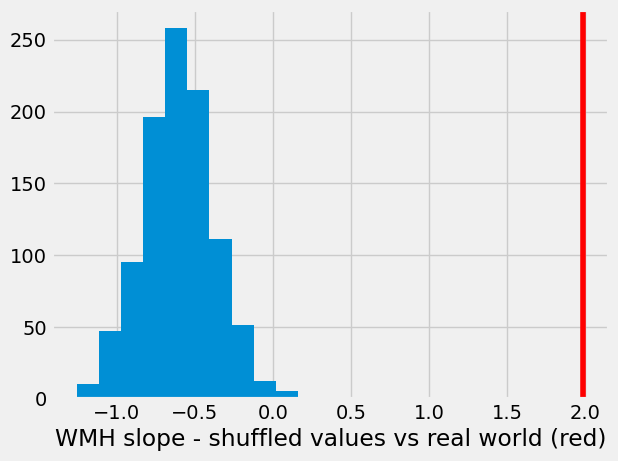

In [102]:
plt.hist(shuffled_pred1_slope)
plt.axvline(x=real_world_pred1_slope,color="red")
plt.xlabel("WMH slope - shuffled values vs real world (red)")

In [103]:
p_value_slope_pred1 = np.count_nonzero(shuffled_pred1_slope >= real_world_pred1_slope)
p_value_slope_pred1

0

### No change here.  Both results match what we found with the regression package.  Now you know quite a lot about multiple regression and how it works.
- It is, however, a complicated area, as you will find out if your predictors are correlated
- You can get unexpected results compared to what you see with just a single variable
    - Note above that pred2 didn't look very interesting on its own
- Running lots of models is not a good idea because each model you run has some chance of looking like a non-random result by chance (that sounds contradictory, but it is not).  
- The best way is to be theory-based.  Run models based on your theory or theories.  Theory will tell you which ones you should be interested in.